<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)

df_2024=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis"))
df_2024_selected=pd.DataFrame(df_2024.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2023=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2023.csv",encoding="shift_jis"))
df_2023_selected=pd.DataFrame(df_2023.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2022=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2022.csv",encoding="shift_jis"))
df_2022_selected=pd.DataFrame(df_2022.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

print(df_2024_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2024_selected.columns)
df_2024_selected.columns

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


Index(['発生曜日', '発生時間帯', '発生場所', '概要', '当事者職種_1', '当事者職種経験（年数）_1',
       '当事者部署配属期間（年数）_1', '事例の内容', '事例の内容.1', '発生要因_当事者の行動に関わる要因',
       '発生要因_ヒューマンファクター', '発生要因_環境・設備機器', '発生要因_その他', '事例の背景要因の概要', '改善策'],
      dtype='object')

In [5]:
df_merged=pd.concat([df_2024_selected,df_2023_selected,df_2022_selected],axis=0,ignore_index=True)
df_merged.to_csv("/content/Medical_Data/df_merged_2.csv")

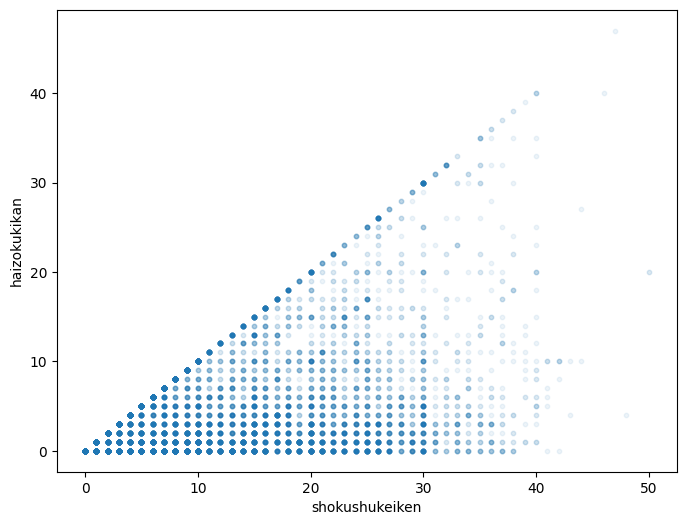

In [6]:
df_clean=df_merged.copy()

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

df_clean = df_clean[df_clean['当事者職種経験（年数）_1'] >= df_clean['当事者部署配属期間（年数）_1']]

fig,ax=plt.subplots(figsize=(8,6))

x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.08)
ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

plt.show()

薬剤ミスの解像度を高めていく。配属年数ごとのミスの違いとか、経験年数ごとのミスの違いとか

In [7]:
df_merged.head()

,発生曜日,発生時間帯,発生場所,概要,当事者職種_1,当事者職種経験（年数）_1,当事者部署配属期間（年数）_1,事例の内容,事例の内容.1,発生要因_当事者の行動に関わる要因,発生要因_ヒューマンファクター,発生要因_環境・設備機器,発生要因_その他,事例の背景要因の概要,改善策
0,水曜日,14:00〜15:59,救急外来,医療機器等,医師,3年,3年,使用中の点検・管理ミス,リカバリー室にいる患者が処置室へ移動する際に医師がストレッチャーを動かした。その際にナースコ...,確認を怠った,NaN,NaN,NaN,未記入,患者を移動させる際はコードや酸素チューブ、点滴が整理されているか確認をする。
1,金曜日,8:00〜9:59,病室,薬剤,看護師,17年,2年,過剰投与,訪室し検査準備をしていると「今、夕方の薬も一緒に飲んでしまった」と患者より報告を受ける。硝酸...,確認を怠った 患者への説明が不十分であった（怠った） 判断を誤った,NaN,NaN,NaN,CAG施行前に硝酸イソソルビド錠20ｍｇ朝一錠内服予定であった。前日夜勤の看護師が朝の分のみ...,夕食後の分は混乱をまねくため、検査後に手渡す。
2,木曜日,8:00〜9:59,病室,薬剤,看護師,4年,4年,過剰与薬準備,術前内服中止薬を内服した。手術当日の夜勤帯看護師が患者に内服錠数を確認すると、医師指示と異な...,確認を怠った 患者への説明が不十分であった（怠った） 判断を誤った,NaN,NaN,その他,前日受け持ちの看護師が、患者へ内服内容を伝えたが口頭のみで伝えた。内服自己管理だったため、持...,内服自己管理でも、中止薬がある際には口頭のみではなく実際に内服薬を取り出し説明をする。患者の...
3,土曜日,12:00〜13:59,病棟処置室,医療機器等,看護師,26年,3年,使用中の点検・管理ミス,発見時、勤務中のスタッフ全員に確認したが該当者はいなかった。アンプル用のごみ箱は数日分をまと...,確認を怠った 判断を誤った,NaN,その他,NaN,未記入,間違ったごみ処理により、収集時や収集後の処理を担当する者に怪我を負わせるリスクがあることを念...
4,月曜日,6:00〜7:59,病室,薬剤,看護師,1年,1年,その他の与薬に関する内容,麻薬が漏れているのを発見した,観察を怠った,技術・手技が未熟だった,NaN,NaN,・6時20分、患者の病室を訪室すると患者の点滴刺入部 付近のシーツが直径15ｃｍ程度濡れてい...,・補液治療を行っている患者は薬剤に関係なく逆血・刺入部の確認を行い正しく薬剤が投与されている...


In [8]:
df_merged['発生要因_当事者の行動に関わる要因'].value_counts()

,count
発生要因_当事者の行動に関わる要因,
確認を怠った,7821
確認を怠った 連携ができていなかった,1617
確認を怠った 観察を怠った,1480
確認を怠った 判断を誤った,754
判断を誤った,473
連携ができていなかった,426
確認を怠った 観察を怠った 連携ができていなかった,401
確認を怠った 連携ができていなかった 判断を誤った,372
観察を怠った,349


In [9]:
!pip install mecab-python3 ipadic networkx japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 109.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 114.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 50.1 MB/s eta 0:00:00
  Created wheel for ipadic: filename=ipadic-1.0.0-py3-none-any.whl size=13556704 sha256=370315890711731bc444ee9314d653c9ddc16a104b34cca746d3f6e07817ae20
  Stored in directory: /root/.cache/pip/wheels/93/8b/55/dd5978a069678c372520847cf84ba2ec539cb41917c00a2206
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=918905a3e0fb7e8590d1d0b8208a9d230d5464a5f45abafa1212c86e80d2e0b3
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built ipadic japanize-matplotlib


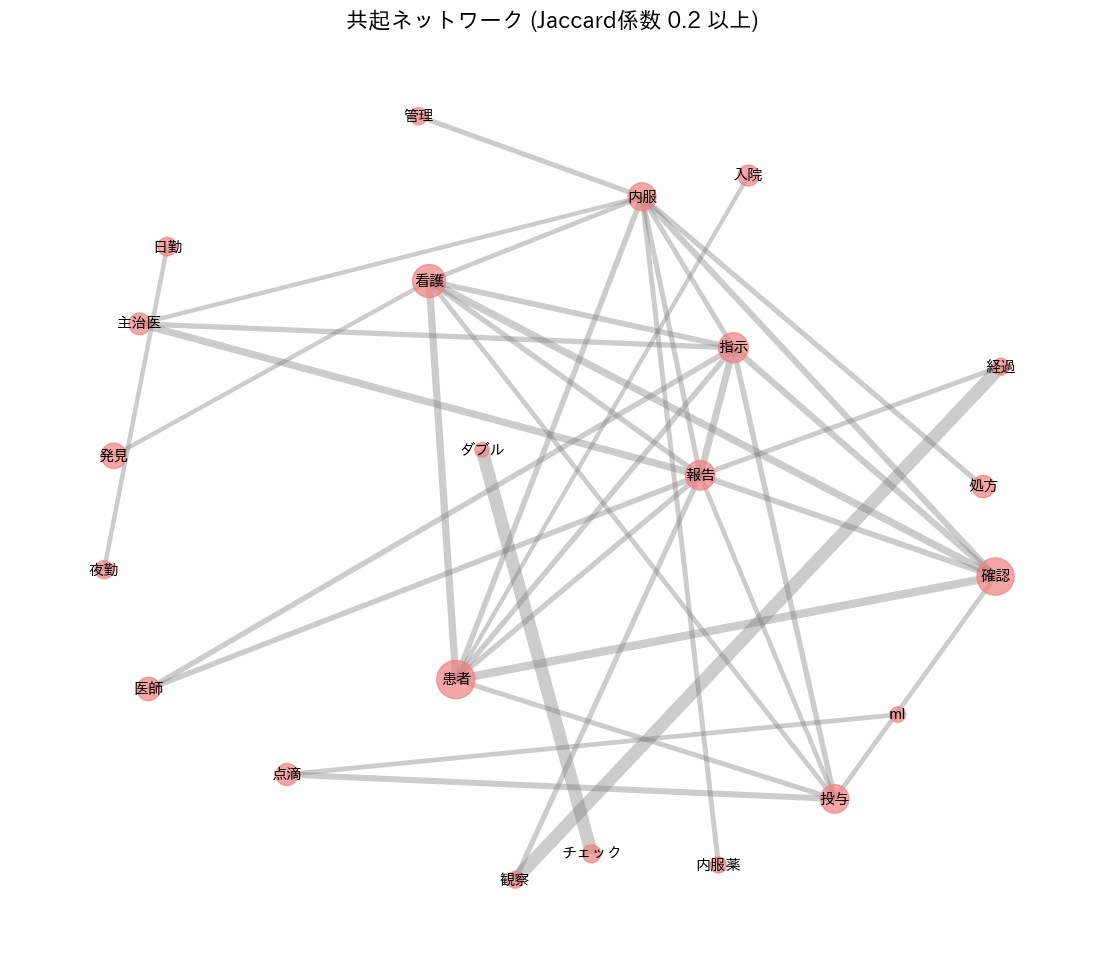

In [10]:
import itertools
from collections import Counter
import MeCab
import ipadic
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import japanize_matplotlib
import math

tagger = MeCab.Tagger(ipadic.MECAB_ARGS)
STOPWORDS = ["こと", "ため", "ところ", "よう", "その後", "10"]

all_words = []
word_lists = []

for text in df_merged['事例の内容.1'].dropna():
    words = []
    node = tagger.parseToNode(str(text))
    while node:
        if node.feature.split(',')[0] == '名詞' and len(node.surface) > 1:
            word_surface = node.surface
            if word_surface not in STOPWORDS:
                words.append(word_surface)
        node = node.next
    unique_words = list(set(words))
    word_lists.append(unique_words)
    all_words.extend(unique_words)

# 単語ごとの「単独での出現行数」を数える
word_counts = Counter(all_words)

# ★上位50語に絞る
frequent_words = [word for word, count in word_counts.most_common(50)]

# 共起ペアのカウント
pair_counts = Counter()
for words in word_lists:
    filtered_words = [w for w in words if w in frequent_words]
    pairs = list(itertools.combinations(sorted(filtered_words), 2))
    pair_counts.update(pairs)

# 5. グラフの作成（Jaccard係数を計算してフィルタリング）
G = nx.Graph()
total_sentences = len(word_lists)

# ★ Jaccard係数のしきい値（0〜1の間。まずは0.15や0.2あたりから試す）
JACCARD_THRESHOLD = 0.20

for (w1, w2), co_count in pair_counts.items():
    # Jaccard係数の計算 formula: n(A∩B) / (n(A) + n(B) - n(A∩B))
    count_a = word_counts[w1]
    count_b = word_counts[w2]
    jaccard = co_count / (count_a + count_b - co_count)

    # 基準以上の特別な関係のペアだけを繋ぐ
    if jaccard >= JACCARD_THRESHOLD:
        G.add_edge(w1, w2, weight=jaccard)

# 6. 可視化
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=1.5, seed=42) # 反発力は強めを維持

node_sizes = [word_counts[node] * 0.08 for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=node_sizes, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_family='IPAexGothic', font_size=11, font_weight='bold')

edges = G.edges()
# Jaccard係数（最大1）に合わせるため、線の太さの倍率を調整
weights = [G[u][v]['weight'] * 15 for u, v in edges]
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='gray', alpha=0.4)

plt.title(f"共起ネットワーク (Jaccard係数 {JACCARD_THRESHOLD} 以上)", fontsize=16)
plt.axis('off')
plt.show()

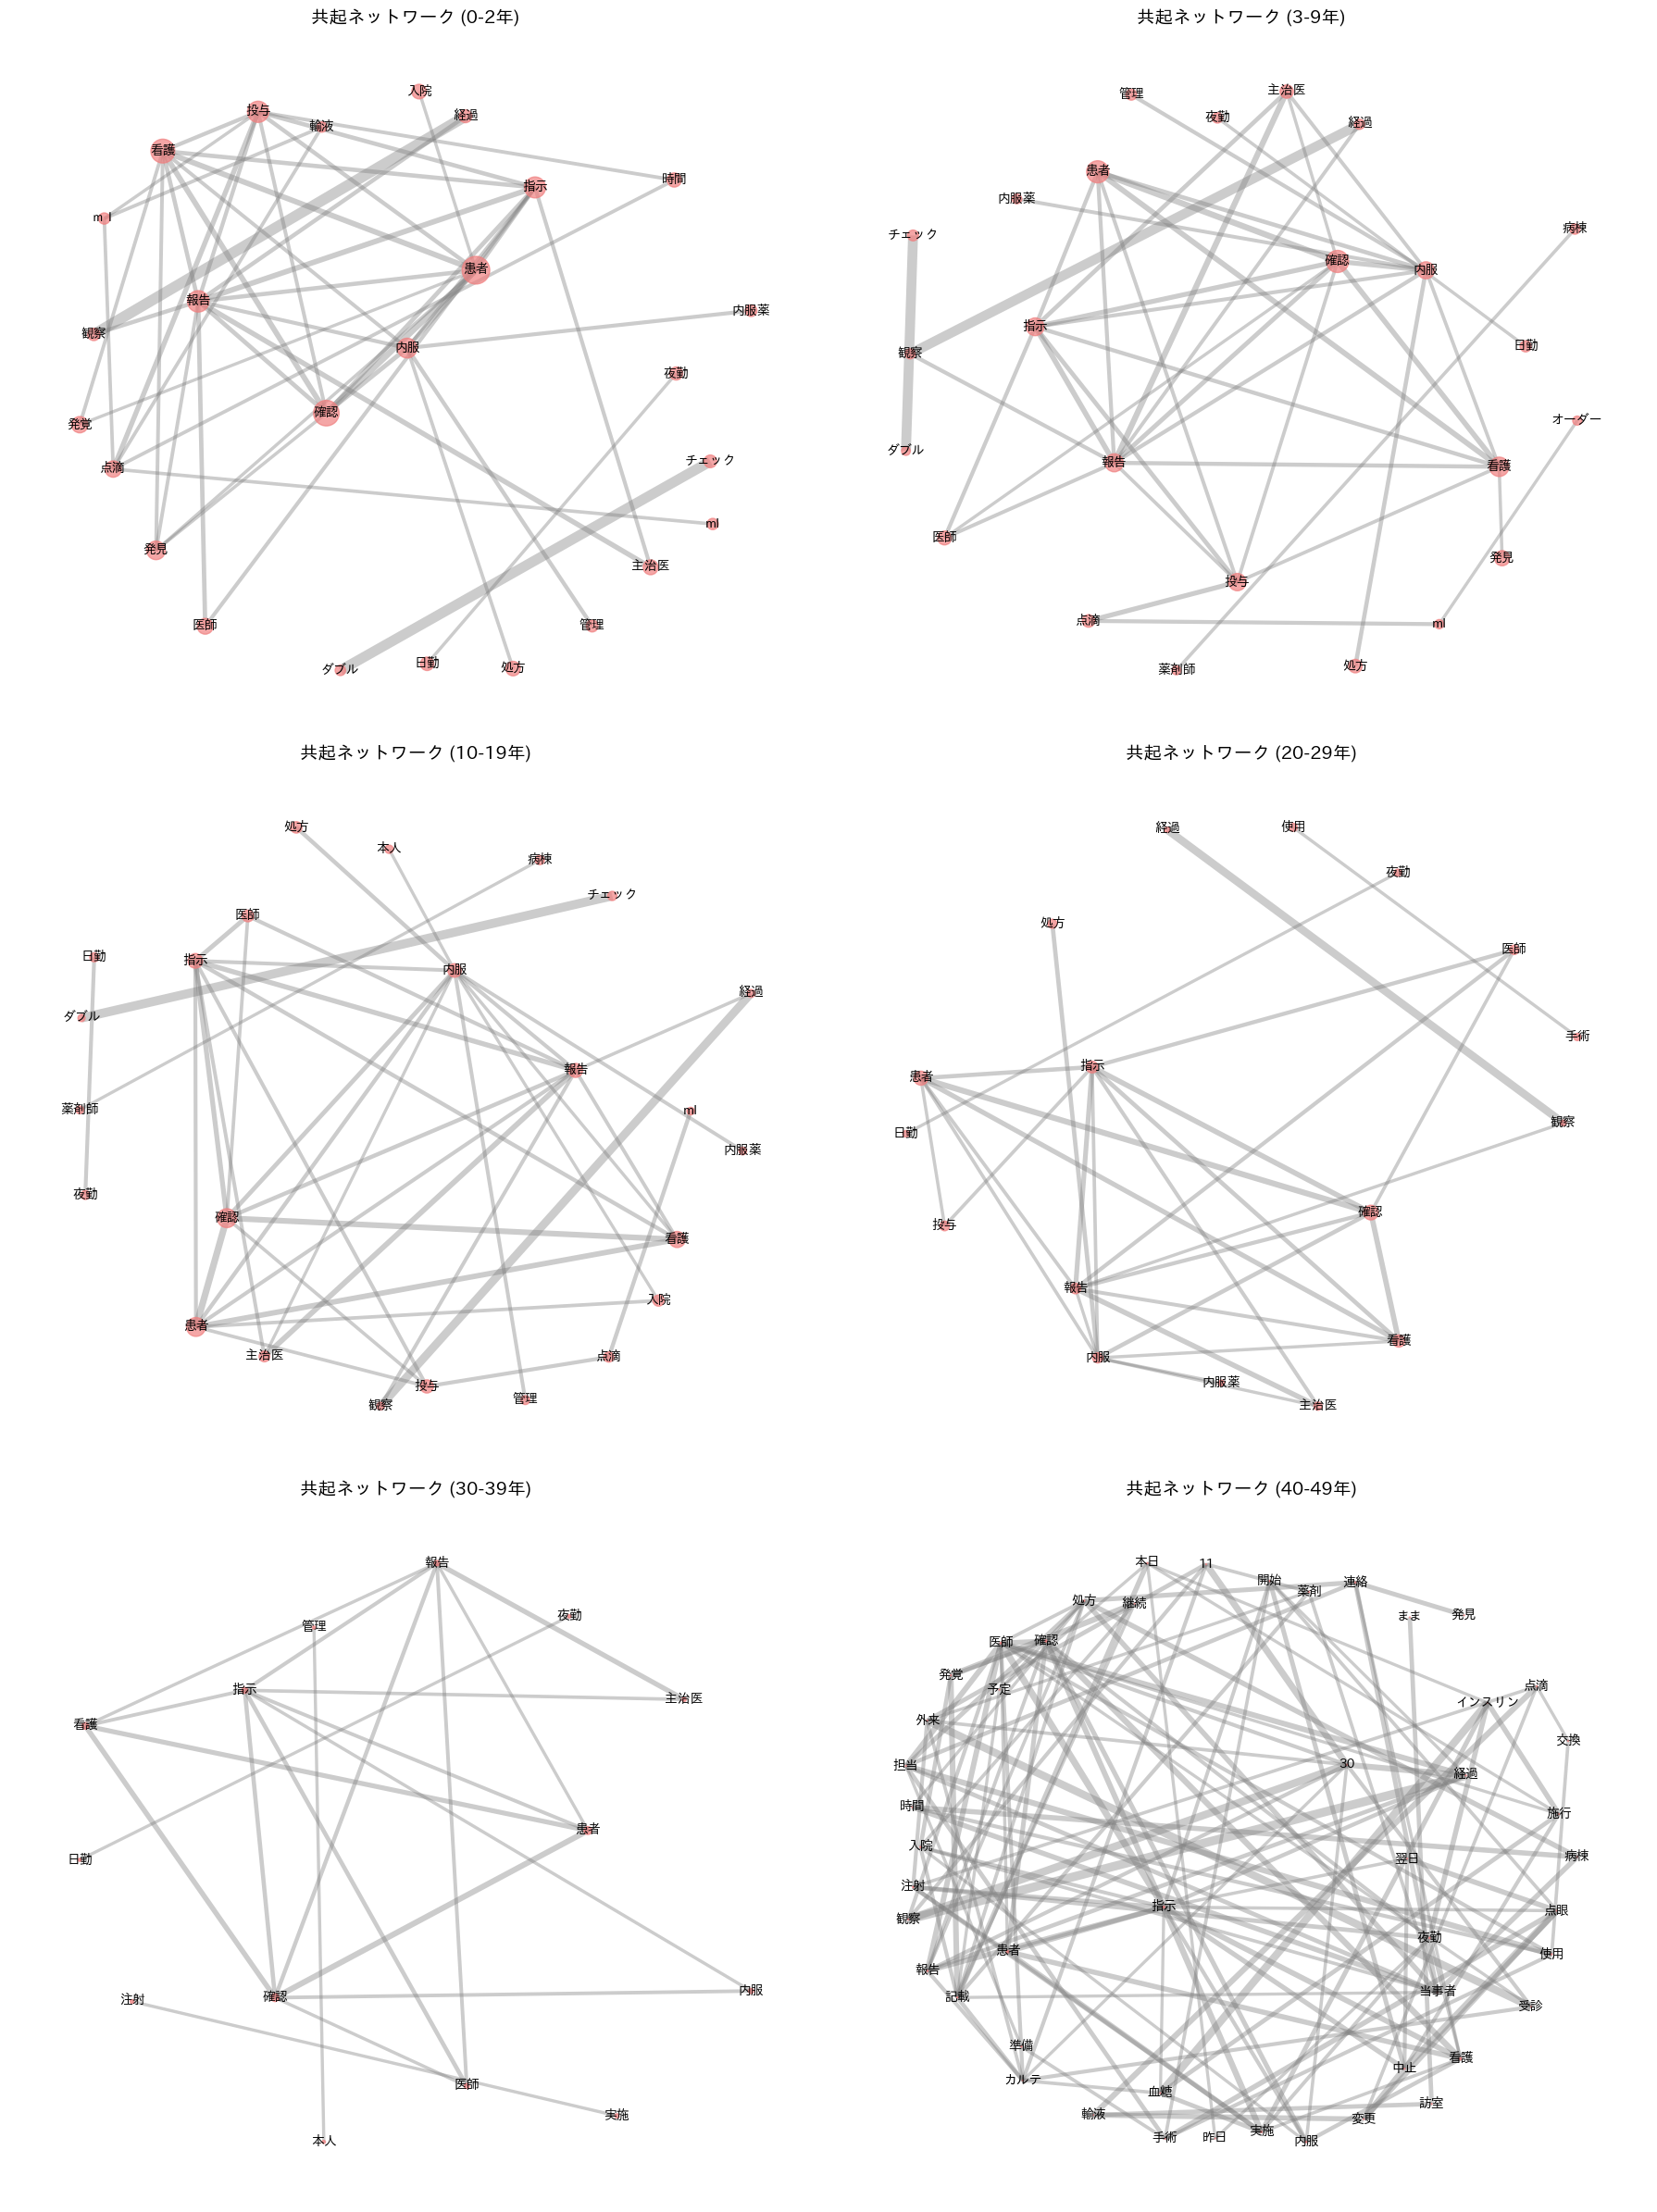

In [11]:
import itertools
from collections import Counter
import MeCab
import ipadic
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import japanize_matplotlib
import math
import re

# 1. データの準備とグループ分け（変則的な区切りに対応）
def get_years_group(years):
    if pd.isna(years):
        return None
    try:
        val_str = str(years).translate(str.maketrans('０１２３４５６７８９', '0123456789'))
        match = re.search(r'\d+', val_str)
        if match:
            val = int(match.group())

            # ★追加：0-2年、3-9年の変則区切り、それ以降は10年ごと
            if 0 <= val <= 2:
                return "0-2年"
            elif 3 <= val <= 9:
                return "3-9年"
            else:
                floor_val = (val // 10) * 10
                return f"{floor_val}-{floor_val + 9}年"
        else:
            return None
    except ValueError:
        return None

# グループ用の新しいカラムを作成
df_merged['経験年数グループ'] = df_merged['当事者職種経験（年数）_1'].apply(get_years_group)

# ★グループの並び順の定義を変更
group_order = ["0-2年", "3-9年", "10-19年", "20-29年", "30-39年", "40-49年"]
# 実際にデータが存在するグループだけを抽出
available_groups = [g for g in group_order if g in df_merged['経験年数グループ'].dropna().unique()]

num_groups = len(available_groups)
if num_groups == 0:
    print("【警告】有効な経験年数データが見つかりませんでした。データを確認してください。")
else:
    num_cols = 2
    num_rows = math.ceil(num_groups / num_cols)

    # 2. 描画エリアの作成
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, 8 * num_rows))
    if num_groups == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    tagger = MeCab.Tagger(ipadic.MECAB_ARGS)
    STOPWORDS = ["こと", "ため", "ところ", "よう", "その後", "10"]
    JACCARD_THRESHOLD = 0.20

    # 3. 各グループごとにネットワークを計算して描画
    for i, group_name in enumerate(available_groups):
        ax = axes[i]
        df_sub = df_merged[df_merged['経験年数グループ'] == group_name]

        all_words = []
        word_lists = []

        for text in df_sub['事例の内容.1'].dropna():
            words = []
            node = tagger.parseToNode(str(text))
            while node:
                if node.feature.split(',')[0] == '名詞' and len(node.surface) > 1:
                    word_surface = node.surface
                    if word_surface not in STOPWORDS:
                        words.append(word_surface)
                node = node.next
            unique_words = list(set(words))
            word_lists.append(unique_words)
            all_words.extend(unique_words)

        if not all_words:
            ax.set_title(f"共起ネットワーク ({group_name}) - データなし", fontsize=14)
            ax.axis('off')
            continue

        # 単語カウントと上位50語の絞り込み
        word_counts = Counter(all_words)
        frequent_words = [word for word, count in word_counts.most_common(50)]

        # 共起ペアのカウント
        pair_counts = Counter()
        for words in word_lists:
            filtered_words = [w for w in words if w in frequent_words]
            pairs = list(itertools.combinations(sorted(filtered_words), 2))
            pair_counts.update(pairs)

        # グラフ作成
        # グラフ作成
        G = nx.Graph()
        for (w1, w2), co_count in pair_counts.items():
            # ★追加：データ数が少ないグループでの「1回きりの偶然の共起」を排除する
            # 全体のデータ量に合わせて、最低共起回数を設定（2回以上など）
            if co_count < 2:
                continue

            count_a = word_counts[w1]
            count_b = word_counts[w2]
            jaccard = co_count / (count_a + count_b - co_count)

            if jaccard >= JACCARD_THRESHOLD:
                G.add_edge(w1, w2, weight=jaccard)

        # サブプロットへの描画
        if len(G.nodes()) > 0:
            pos = nx.spring_layout(G, k=1.5, seed=42)
            node_sizes = [word_counts[node] * 0.12 for node in G.nodes()]

            nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=node_sizes, alpha=0.7, ax=ax)
            nx.draw_networkx_labels(G, pos, font_family='IPAexGothic', font_size=10, font_weight='bold', ax=ax)

            edges = G.edges()
            weights = [G[u][v]['weight'] * 12 for u, v in edges]
            nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, edge_color='gray', alpha=0.4, ax=ax)
        else:
            ax.text(0.5, 0.5, 'しきい値以上の共起なし', horizontalalignment='center', verticalalignment='center')

        ax.set_title(f"共起ネットワーク ({group_name})", fontsize=14)
        ax.axis('off')

    # 余ったサブプロットを非表示にする
    for j in range(num_groups, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [39]:
df_kai=df_merged.loc[:,["当事者職種経験（年数）_1","発生要因_ヒューマンファクター"]]

df_kai['当事者職種経験（年数）_1']=df_kai['当事者職種経験（年数）_1'].astype(str).str.replace("00","0").str.replace("年","").astype(int)
df_kai['発生要因_ヒューマンファクター']=df_kai['発生要因_ヒューマンファクター'].str.split(r'\s+')

df_kai=df_kai.explode('発生要因_ヒューマンファクター')

bins = [-1, 0, 1, 3, 10, 20, 30,  np.inf]
labels = ["0年目", "1年目", "2〜3年目", "4〜10年目", "11～20年目","21～30年目","31年目以上"]
df_kai["経験年数グループ"] = pd.cut(df_kai['当事者職種経験（年数）_1'], bins=bins, labels=labels)

cross_table=pd.crosstab(df_kai["経験年数グループ"],df_kai['発生要因_ヒューマンファクター'])

data_ndarray=cross_table.values

chi2, p, dof, expected = stats.chi2_contingency(data_ndarray)
print(f"p値: {p:.4f}")

p値: 0.0000


In [37]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. 通常のカイ2乗検定で「期待度数」を取得
# ※ cross_table は pd.crosstab() で作った DataFrame
observed = cross_table.values
chi2, p, dof, expected = stats.chi2_contingency(observed)

# 2. 調整済み標準化残差の計算
n = observed.sum()  # 総サンプル数（16000件）
row_totals = observed.sum(axis=1, keepdims=True)  # 各行の合計
col_totals = observed.sum(axis=0, keepdims=True)  # 各列の合計

# 各セルの分散の分母を計算
variance = expected * (1 - row_totals / n) * (1 - col_totals / n)

# 調整済み標準化残差 ＝ (実測度数 - 期待度数) / 💡(分散の平方根)
adjusted_residuals = (observed - expected) / np.sqrt(variance)

# 3. DataFrameの形に戻す
df_residuals = pd.DataFrame(
    adjusted_residuals, index=cross_table.index, columns=cross_table.columns
)

print(df_residuals)

発生要因_ヒューマンファクター        その他  勤務状況が繁忙だった  技術・手技が未熟だった  知識が不足していた  \
経験年数グループ                                                         
0年目              24.871941  -18.299923     1.538827  -2.929945   
1年目             -10.907868    0.179310     5.317987   3.838833   
2〜3年目            -9.640483    4.222953     1.393862   2.156632   
4〜10年目           -7.924084    7.093242    -2.392351   0.145824   
11～20年目          -3.804698    6.293197    -2.751032   0.123808   
21～30年目           0.493301    5.379076    -2.475051  -2.210976   
31年目以上           -0.163264    2.209220    -2.651371  -1.284475   

発生要因_ヒューマンファクター  通常とは異なる心理的条件下にあった  通常とは異なる身体的条件下にあった  
経験年数グループ                                               
0年目                       2.723424          -3.638204  
1年目                       1.291138           0.753792  
2〜3年目                     0.748362          -0.639905  
4〜10年目                   -0.308254           2.347830  
11～20年目                  -2.391829           0.261958  
21～30年目      

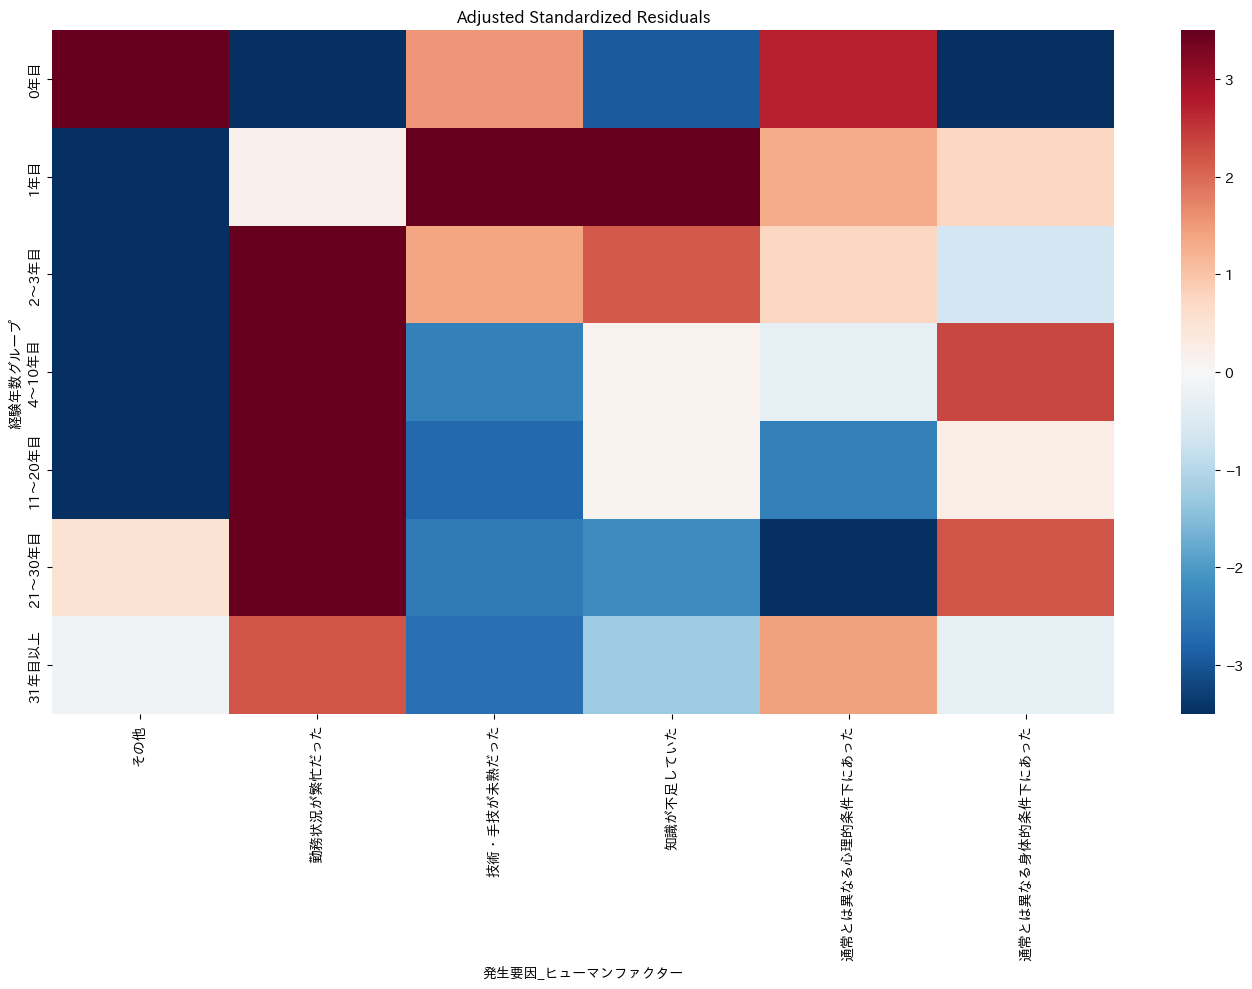

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# 0を中心に、プラス（赤）とマイナス（青）が綺麗に分かれるカラーマップ「RdBu_r」を使用
# vmin, vmaxを±3.3くらいに設定すると、目立つ場所だけが濃くなるよ
sns.heatmap(
    df_residuals,
    annot=False,  # 件数が多いならFalse、見たいならTrue
    cmap="RdBu_r",
    center=0,
    vmin=-3.5,
    vmax=3.5,
)

plt.title("Adjusted Standardized Residuals")
plt.tight_layout()
plt.show()

0年のその他、ベテランは通常と異なる状況下で起きる傾向が高い